## PCA

### Task 1: Exploratory Data Analysis (EDA):

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model  import LogisticRegression
from sklearn.decomposition import PCA

In [2]:
## load dataset
df=pd.read_csv('wine.csv')
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.shape

(178, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
## missing value
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [7]:
## duplicates
df.duplicated().sum()

np.int64(0)

<Axes: >

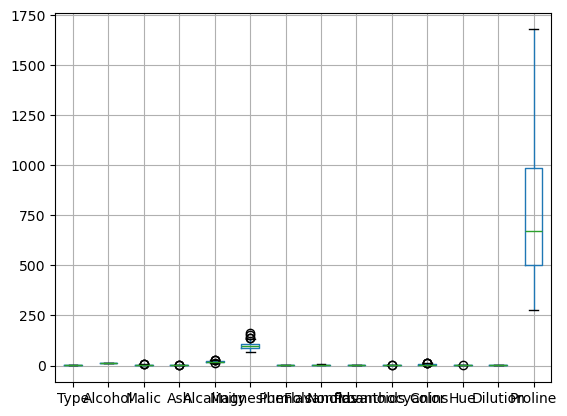

In [8]:
df.boxplot()

In [9]:
## outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR =Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

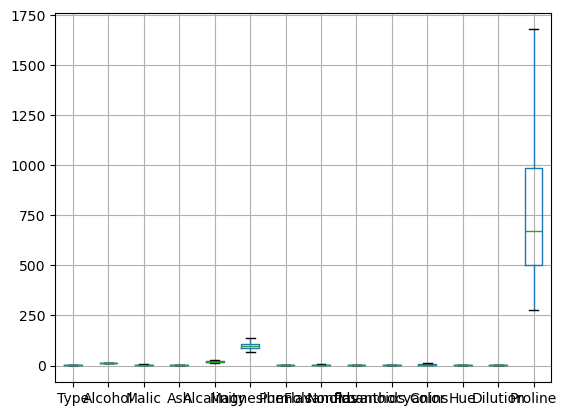

In [10]:
df.boxplot()
plt.show()

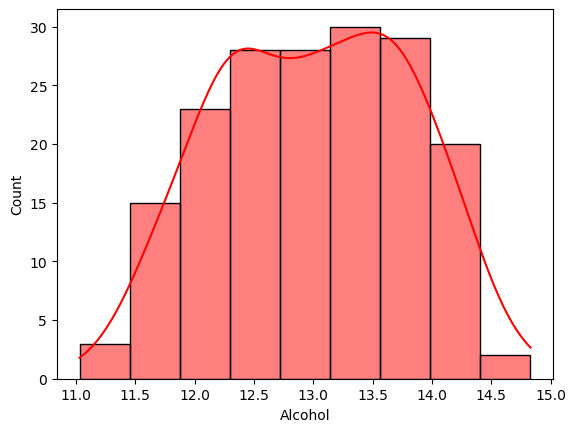

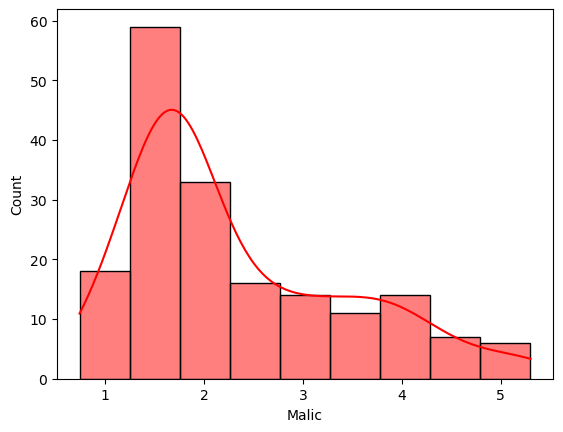

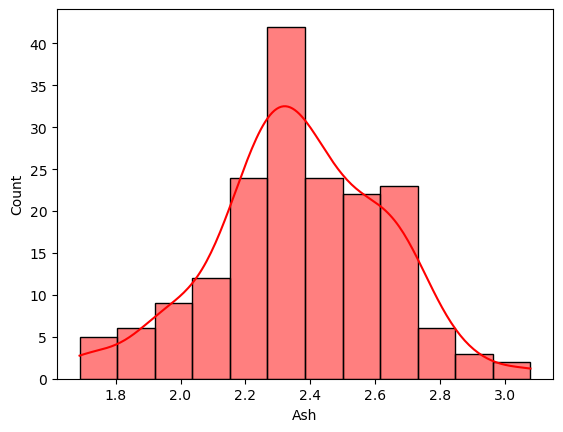

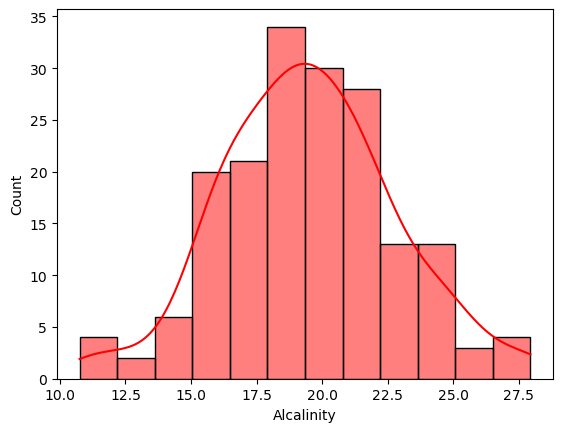

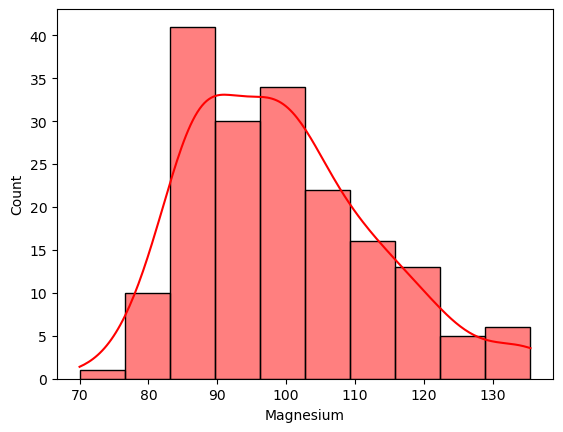

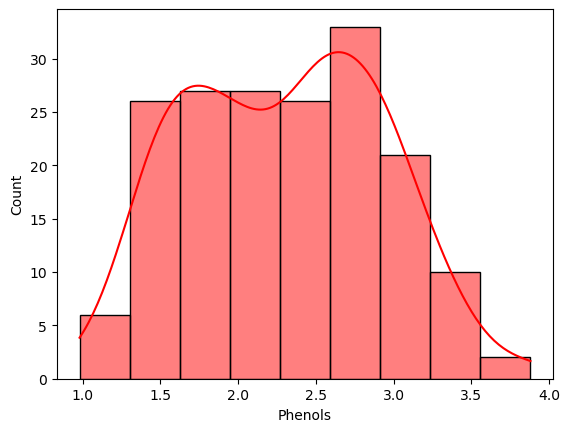

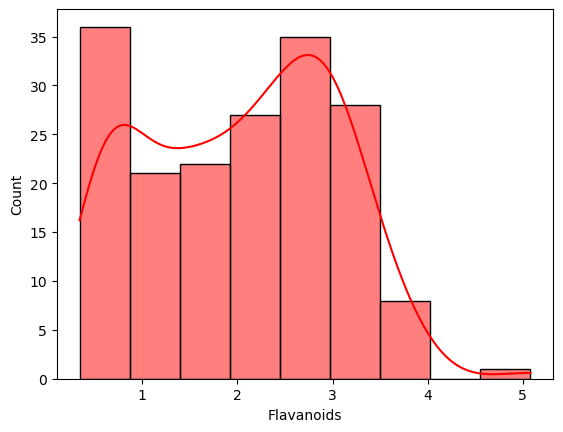

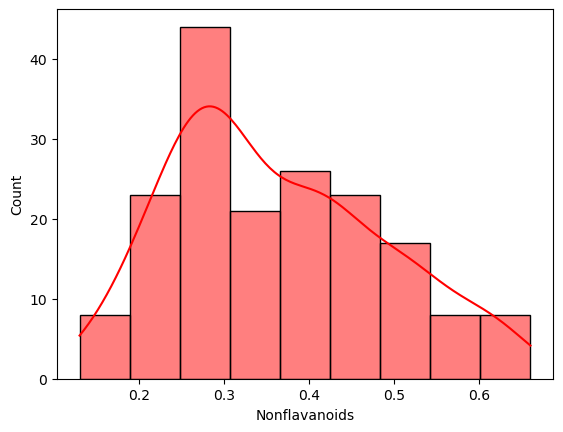

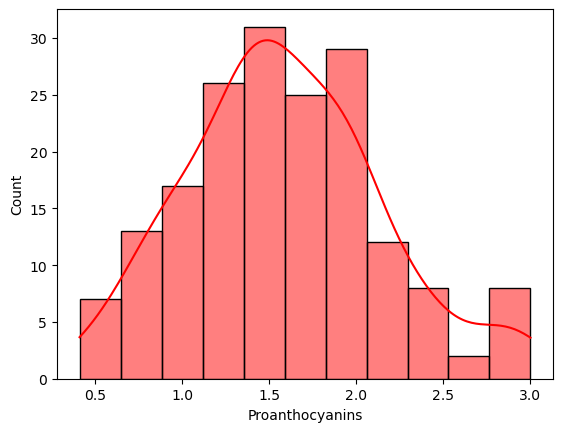

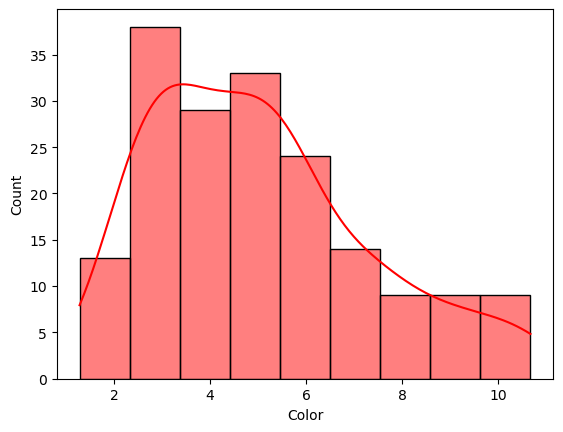

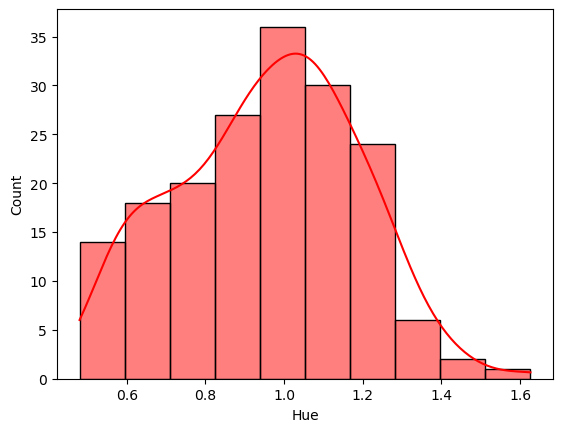

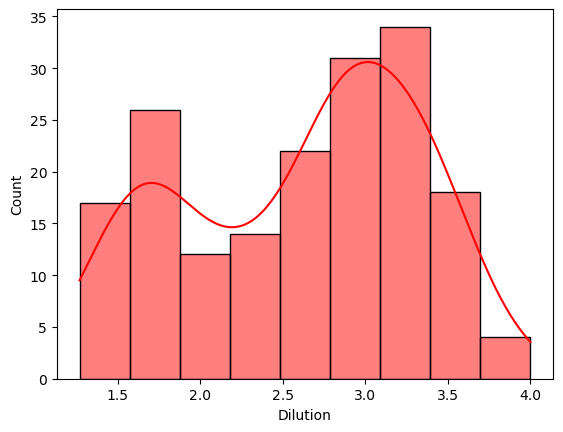

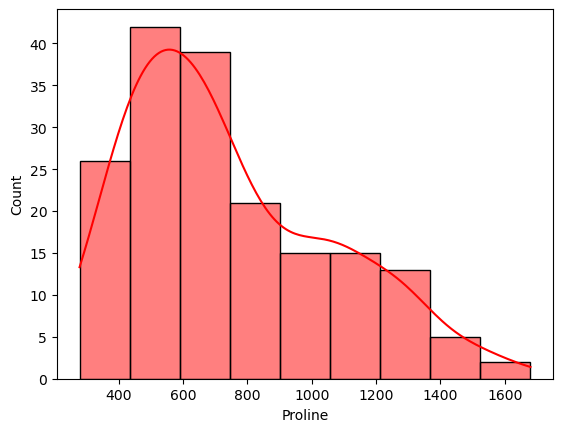

In [11]:
## histogram
for col in df.drop(columns=['Type']):
 sns.histplot(data=df,x=col,color='red',kde=True)
 plt.show()

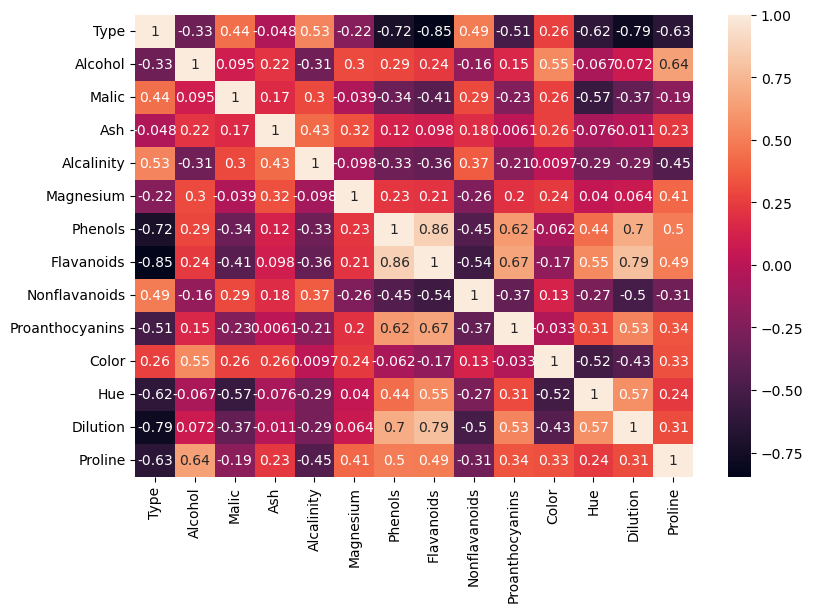

In [12]:
## correlation
corr=df.corr()
plt.figure(figsize=(9,6))
sns.heatmap(corr,annot=True)
plt.show()

### Task 2: Dimensionality Reduction with PCA:

In [13]:
target=df['Type']
features=df.drop(columns=['Type'])

In [14]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.75,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(133, 13)
(45, 13)
(133,)
(45,)


In [15]:
std_sca=StandardScaler()
x_train_scale=pd.DataFrame(std_sca.fit_transform(x_train),columns=x_train.columns)
x_test_scale=pd.DataFrame(std_sca.transform(x_test),columns=x_test.columns)

In [16]:
## PCA 
pca=PCA()
pca.fit(x_train_scale)

PCA()

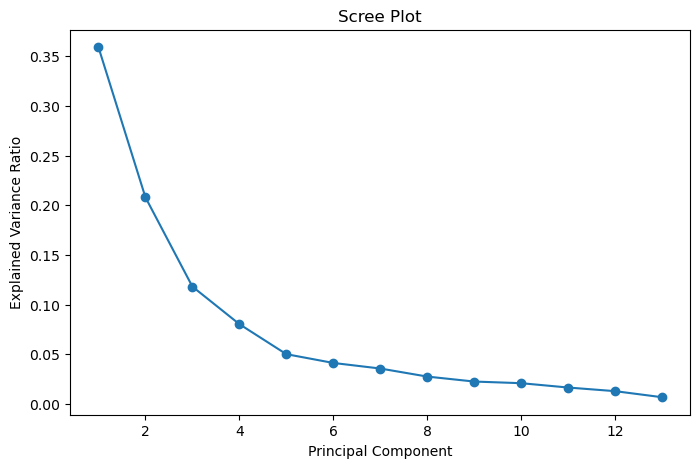

In [17]:
## Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

In [18]:
## PCA with optimal number
pca=PCA(n_components=4)
pca.fit(x_train_scale)

PCA(n_components=4)

In [19]:
x_train_new=pca.transform(x_train)
x_test_new=pca.transform(x_test)

In [20]:
x_train_new.shape,x_test_new.shape

((133, 4), (45, 4))

### Task 3: Clustering with Original Data:

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [22]:
kmeans=KMeans(n_clusters=4,random_state=42)
clusters = kmeans.fit_predict(x_train_scale)

In [23]:
silhouette_score(x_train_scale,clusters)

np.float64(0.26346204086791375)

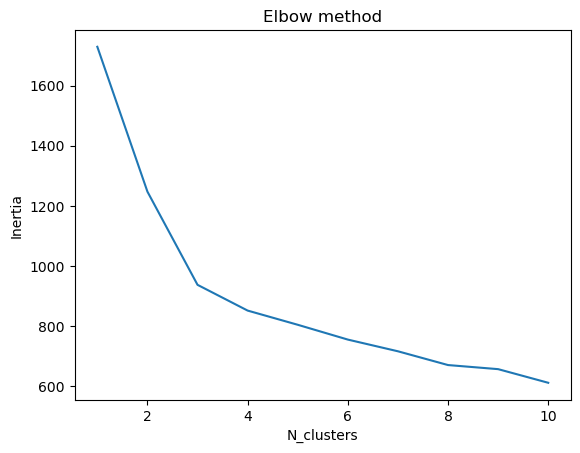

In [24]:
inertia=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(x_train_scale)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,11),inertia)
plt.xlabel('N_clusters')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

In [25]:
print("Inertia:", kmeans.inertia_)
print("Unique clusters:", np.unique(clusters))

Inertia: 610.2083697138249
Unique clusters: [0 1 2 3]


In [26]:
kmeans=KMeans(n_clusters=3)
labels = kmeans.fit_predict(x_train_scale)

In [27]:
np.unique(clusters)

array([0, 1, 2, 3], dtype=int32)

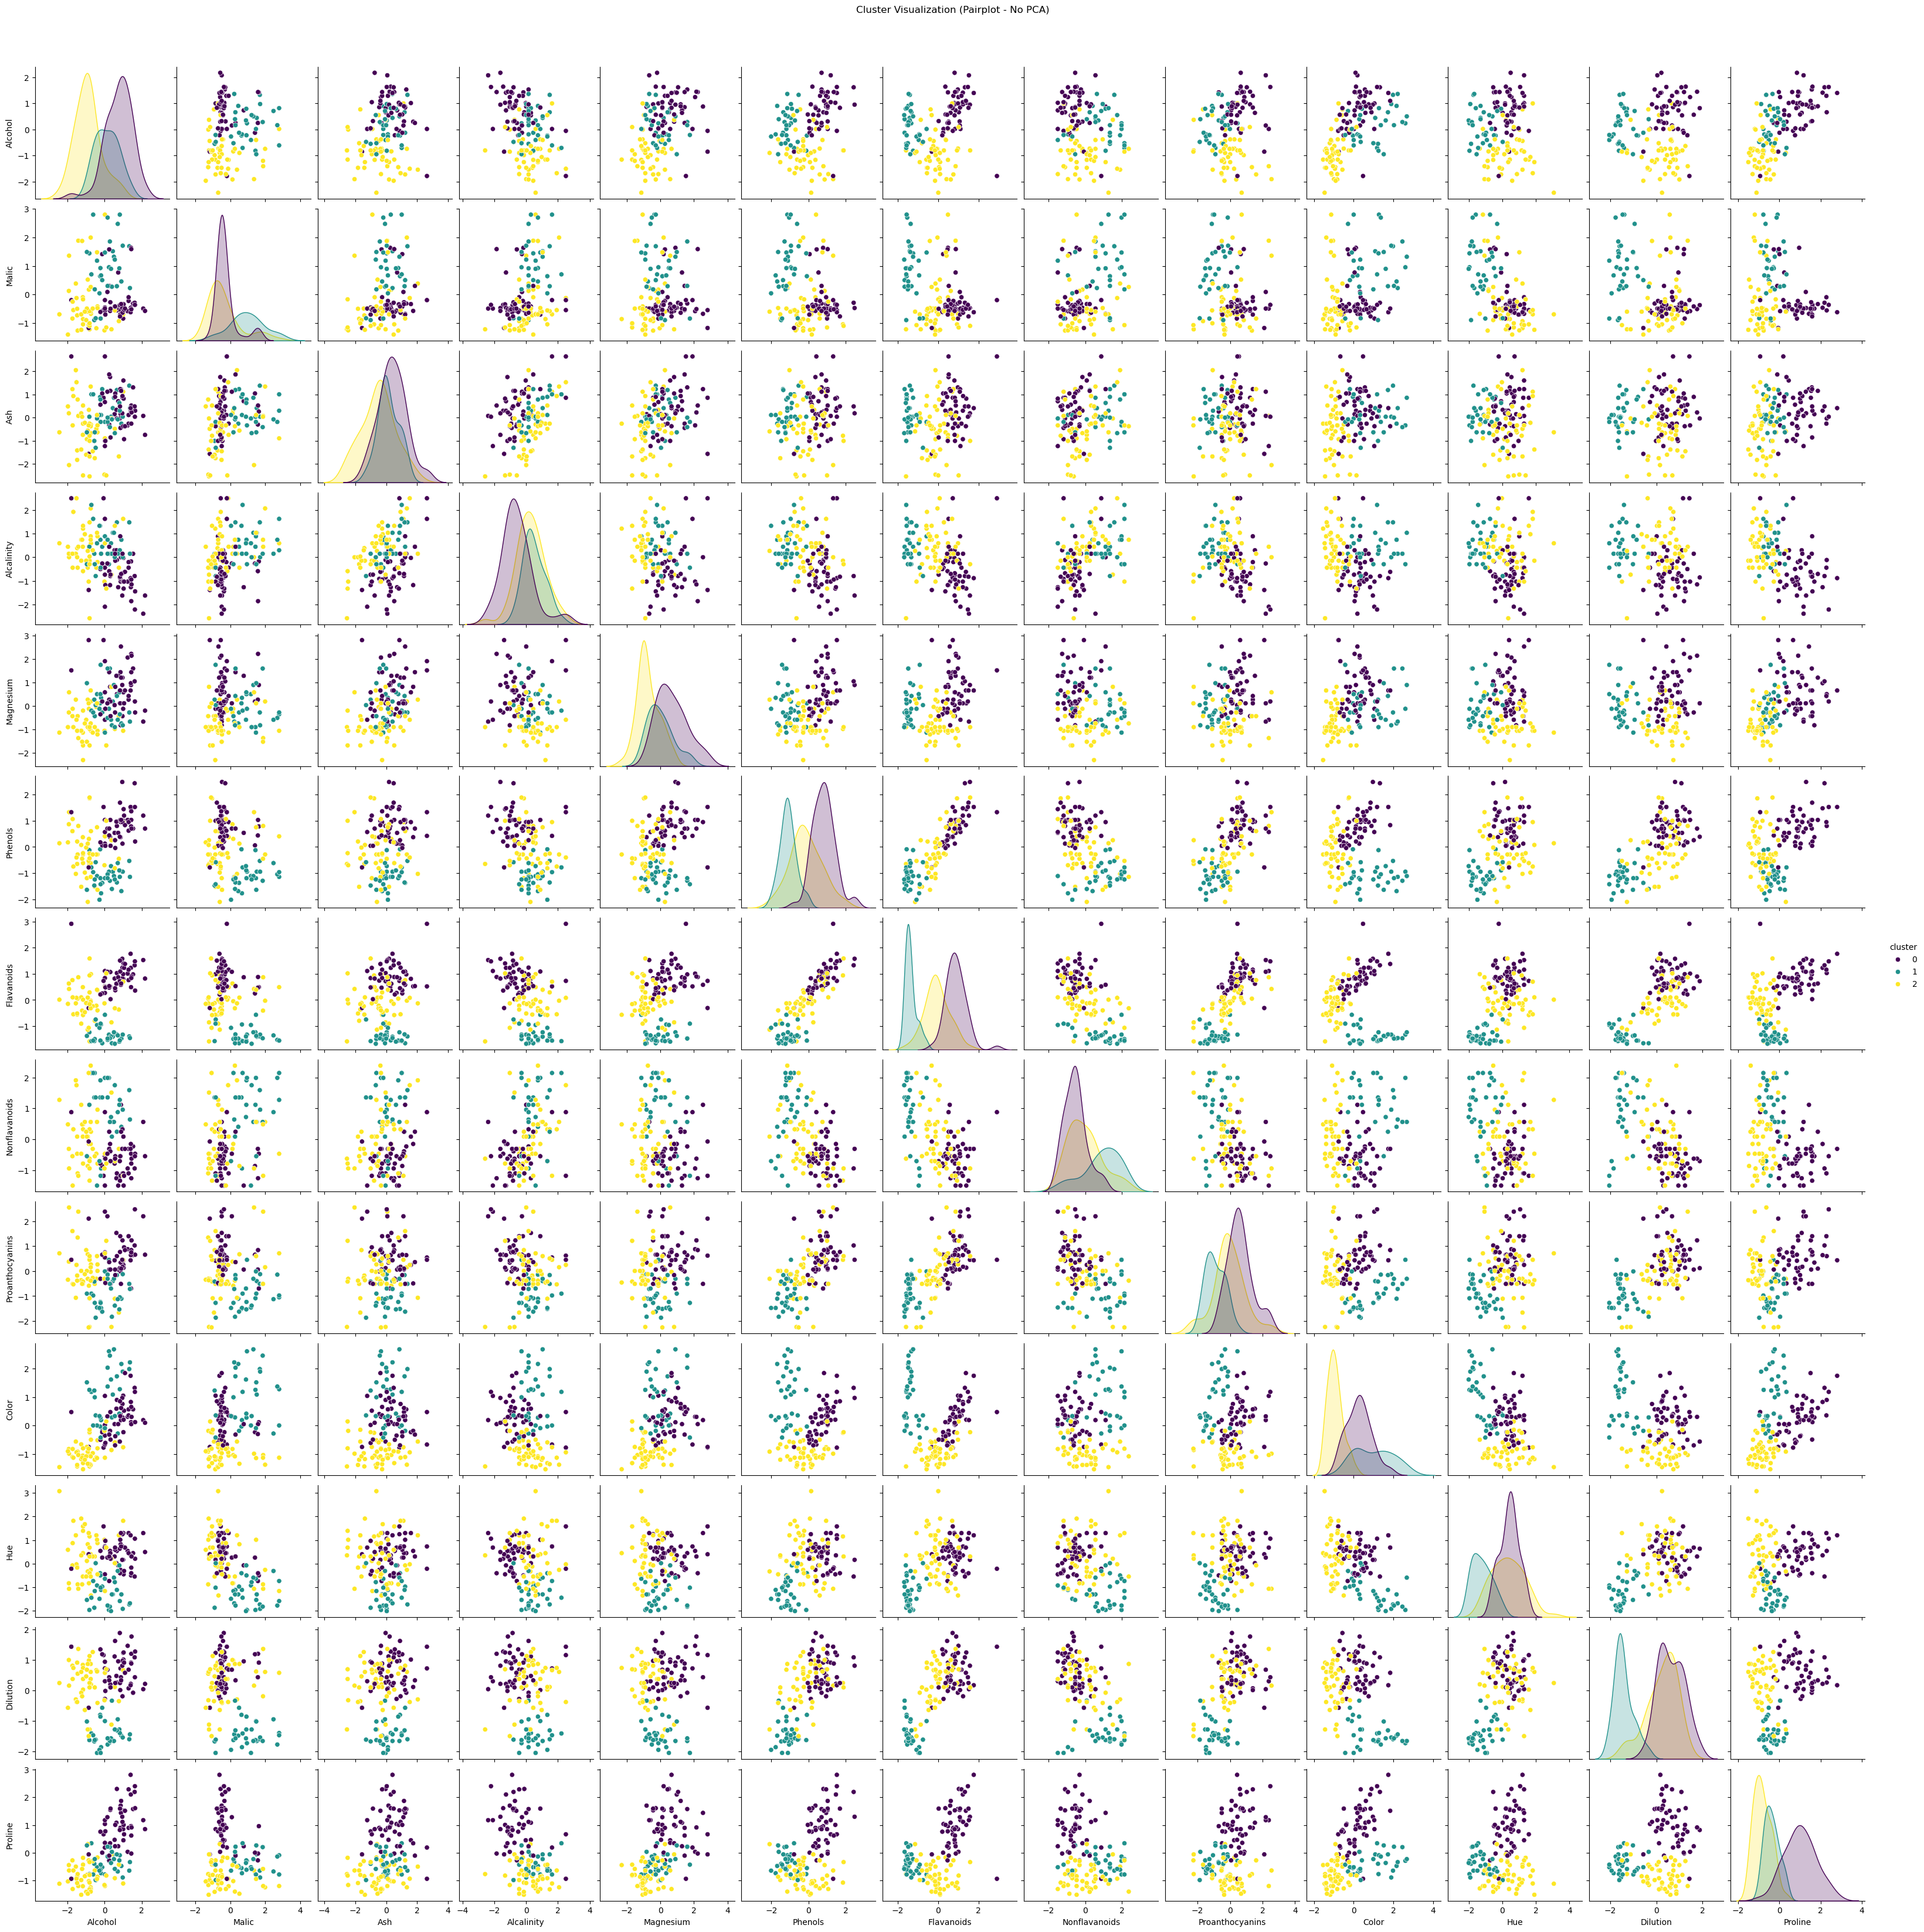

In [28]:
temp = pd.DataFrame(x_train_scale,columns=x_train.columns)
temp["cluster"] = labels
sns.pairplot(temp,hue='cluster',palette='viridis')
plt.suptitle("Cluster Visualization (Pairplot - No PCA)", y=1.02)
plt.show()

In [29]:
## silhouette score
silhouette_score(x_train_scale,labels)

np.float64(0.2926926477223237)

### Task 4: Clustering with PCA Data:

In [30]:
kmeans_pca=KMeans(n_clusters=4,random_state=42)
labels_pca = kmeans_pca.fit_predict(x_train_new)

In [32]:
silhouette_score(x_train_new,labels_pca)

np.float64(0.5486786873170654)

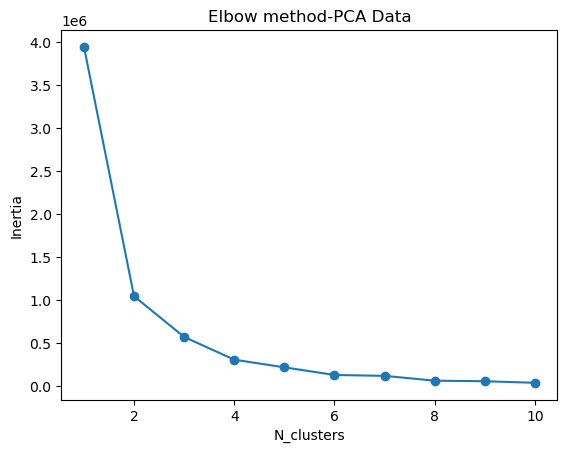

In [33]:
inertia=[]
for i in range(1,11):
    km=KMeans(n_clusters=i)
    km.fit(x_train_new)
    inertia.append(km.inertia_)
plt.plot(range(1,11),inertia,marker='o')
plt.xlabel('N_clusters')
plt.ylabel('Inertia')
plt.title('Elbow method-PCA Data')
plt.show()

In [34]:
kmeans_pca=KMeans(n_clusters=3)
labels_pca = kmeans_pca.fit_predict(x_train_new)

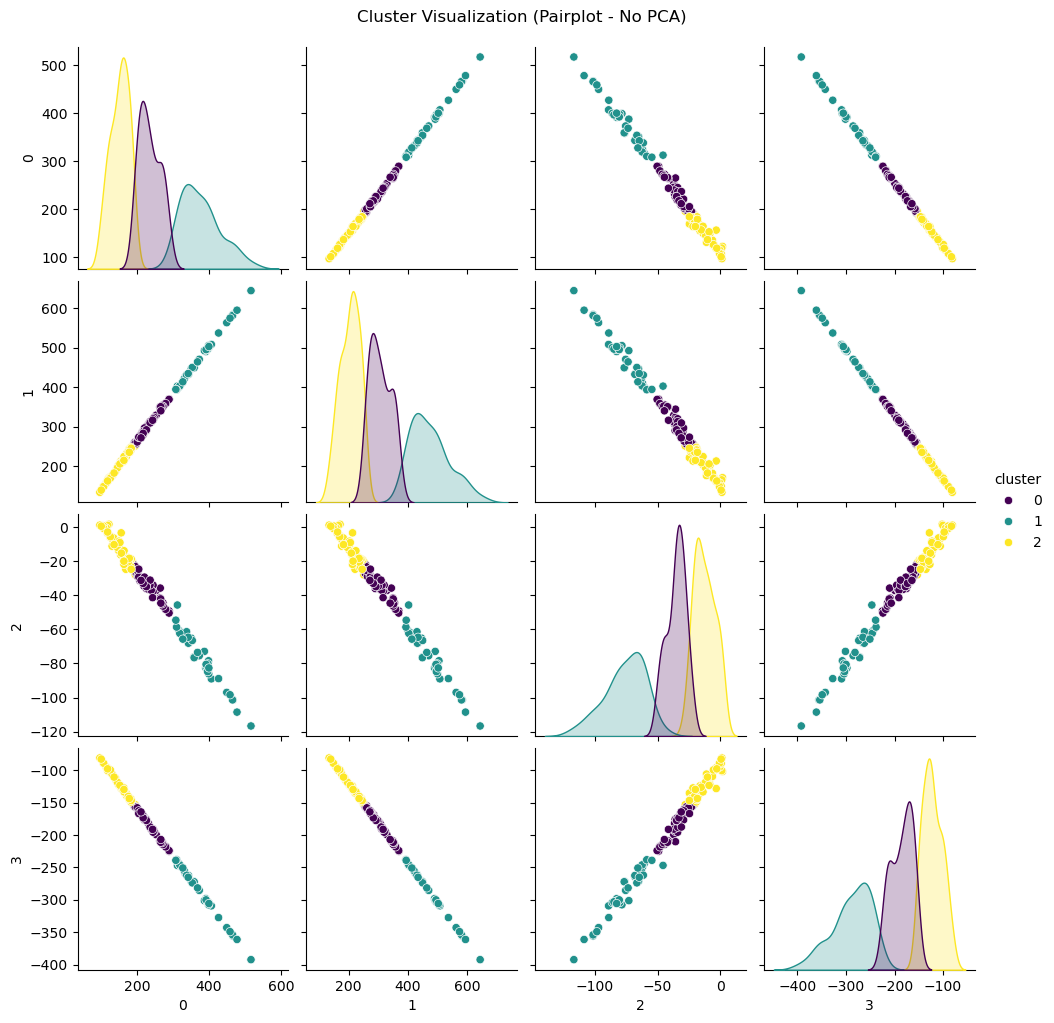

In [35]:
temp = pd.DataFrame(x_train_new)
temp["cluster"] = labels_pca
sns.pairplot(temp,hue='cluster',palette='viridis')
plt.suptitle("Cluster Visualization (Pairplot - No PCA)", y=1.02)
plt.show()

In [ ]:
## silhouette score
silhouette_score(x_train_new,labels_pca)

### Task 5: Comparison and Analysis:

## Task 6: Conclusion and Insights